# Temporal LSTM v2 — Sequence Model (`P_seq`)

Sequence track for AWS privilege-escalation detection.

- **Model:** `temporal_lstm_v2` (masked BiLSTM + attention, bag of 5)
- **Data:** `data/lstm/train_temporal.csv` — official Invictus + fe-final CloudTrail (union vocab, usernames prefixed `inv:` / `fe:`)
- **Output:** `P_seq` per 10-min window → fusion with `P_graph`

This notebook has the full pipeline: features, windowing, architecture, training, evaluation, and plots.


## 1. Imports and config


In [1]:
# Libraries + paths + hyperparameters for the whole pipeline.
# Constants live here so the experiment stays reproducible.

from __future__ import annotations

import json
import math
import random
from collections import Counter
from dataclasses import dataclass
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from IPython.display import display
from sklearn.metrics import (
    average_precision_score,
    confusion_matrix,
    f1_score,
    precision_recall_curve,
    precision_score,
    recall_score,
    roc_auc_score,
    roc_curve,
)
from sklearn.model_selection import GroupShuffleSplit
from torch.utils.data import DataLoader, Dataset

# Input / output locations
ROOT = Path(".").resolve()
CSV_PATH = ROOT / "data" / "lstm" / "train_temporal.csv"
VOCAB_PATH = ROOT / "data" / "lstm" / "event_name_vocab.json"
OUT_DIR = ROOT / "artifacts"
PLOT_DIR = OUT_DIR / "plots"
OUT_DIR.mkdir(parents=True, exist_ok=True)
PLOT_DIR.mkdir(parents=True, exist_ok=True)

# Fixed seed for reproducibility; bag uses 5 seeds and averages probs
SEED = 42
BAG_SEEDS = [42, 43, 44, 45, 46]

# 10-min windows, slide every 2 min
WINDOW_MINUTES = 10
STRIDE_MINUTES = 2

# Max events kept per window (pad shorter, truncate longer)
SEQ_LEN = 32

# Model size: embed API names, BiLSTM(64), attention over real steps
EMBED_DIM = 32
HIDDEN_DIM = 64
LSTM_LAYERS = 1
DROPOUT = 0.4
ATTN_DROPOUT = 0.1

BATCH_SIZE = 64
LR = 1e-3
WEIGHT_DECAY = 1e-3
MAX_EPOCHS = 60
PATIENCE = 12  # early-stop if val AUC-PR stalls

SCHEMA_VERSION = "temporal_lstm_v2.1"
# Not fed as numeric features
META_COLS = {"log_id", "username", "timestamp", "label", "event_name_idx"}
THR_TRIAGE = 0.55  # soft triage bar; alert threshold tuned on val later

# True = train here. False = load artifacts/temporal_lstm_v2.pt
RUN_TRAIN = False


def set_seed(seed: int = SEED) -> None:
    # Same RNG state across numpy / torch so runs match
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)


set_seed()
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("device:", device)
print("csv:", CSV_PATH)
print("RUN_TRAIN:", RUN_TRAIN)


device: cpu
csv: C:\Users\nanda\OneDrive\Desktop\Capstone-2027\data\lstm\train_temporal.csv
RUN_TRAIN: False


## 2. Load and validate data

Merged official Invictus + fe-final CloudTrail (`prepare_lstm_dataset.py`). Schema: 40 columns, event labels, `event_name_idx` from the union vocab (fe-final IDs 1–67 frozen; Invictus-only APIs appended). Usernames are `fe:` / `inv:` so windows never mix sources.


In [2]:
# Load merged CSV (Invictus + fe-final), sanity-check schema, vocab size.
# Index 0 is PAD/UNK; vocab_size = max(event_name_idx) + 1 (union map in event_name_vocab.json).

df = pd.read_csv(CSV_PATH)
assert df.shape[1] == 40, df.shape
df["timestamp"] = pd.to_datetime(df["timestamp"], utc=True)

# Required columns must be complete; need at least one attack row
for col in ["username", "timestamp", "event_name_idx", "label"]:
    assert df[col].isna().sum() == 0, col
assert int(df["event_name_idx"].min()) >= 1
assert int(df["label"].sum()) > 0

# 35 engineered numeric columns (everything except meta)
FEATURE_COLS = [c for c in df.columns if c not in META_COLS]
assert len(FEATURE_COLS) == 35, len(FEATURE_COLS)
VOCAB_SIZE = int(df["event_name_idx"].max()) + 1

# Optional name map stored later inside the checkpoint
vocab = {}
if VOCAB_PATH.exists():
    vocab = json.loads(VOCAB_PATH.read_text(encoding="utf-8"))

print("shape:", df.shape)
print("features:", len(FEATURE_COLS))
print("vocab_size:", VOCAB_SIZE)
print("users:", df["username"].nunique())
print("label counts:\n", df["label"].value_counts().to_string())
print("time:", df["timestamp"].min(), "->", df["timestamp"].max())
df.head(3)


shape: (12611, 40)
features: 35
vocab_size: 281
users: 583
label counts:
 label
0    11995
1      616
time: 2023-07-10 11:42:18+00:00 -> 2024-12-28 10:21:58+00:00


,log_id,username,timestamp,no_mfa,mfa_absent,principal_type_prior_risk,principal_type_idx,has_access_key,action_velocity,is_new_action,...,targets_sensitive_resource,is_non_default_region,is_create_key,is_secrets_or_kms,is_permission_modification,policy_statement_count_normalized,has_wildcard_action,has_wildcard_resource,privileged_action_reach,label
0,synthetic_cloudtrail.csv:2141,fe:AWSServiceRoleForEC2,2024-03-24 07:00:19+00:00,1,0,0.5,3,1,0.000000,1,...,0,0,0,0,0,0.0,0,0,0.0,0
1,synthetic_cloudtrail.csv:2142,fe:AWSServiceRoleForEC2,2024-03-24 07:00:40+00:00,1,0,0.5,3,1,0.994167,1,...,0,0,0,0,0,0.0,0,0,0.0,0
2,synthetic_cloudtrail.csv:2143,fe:AWSServiceRoleForEC2,2024-03-24 07:01:07+00:00,1,0,0.5,3,1,0.992500,1,...,0,0,0,0,0,0.0,0,0,0.0,0


## 3. Feature columns

The 35 engineered features come from the shared FE temporal schema. Windowing also adds **`delta_t_log1p`** (log1p seconds between consecutive events), so each timestep is **36 numeric features + event embedding**.


In [3]:
# Print all feature names, then rank by |attack mean - benign mean|.
# Helps show which signals differ most between attack and normal activity.

print("=== 35 base feature columns ===")
for i, c in enumerate(FEATURE_COLS, 1):
    print(f"{i:2d}. {c}")

pos = df[df["label"] == 1]
neg = df[df["label"] == 0]
cmp = pd.DataFrame({
    "mean_attack": pos[FEATURE_COLS].mean(),
    "mean_benign": neg[FEATURE_COLS].mean(),
})
cmp["abs_diff"] = (cmp["mean_attack"] - cmp["mean_benign"]).abs()
print("\nTop features by |mean_attack - mean_benign|:")
display(cmp.sort_values("abs_diff", ascending=False).head(12).round(4))


=== 35 base feature columns ===
 1. no_mfa
 2. mfa_absent
 3. principal_type_prior_risk
 4. principal_type_idx
 5. has_access_key
 6. action_velocity
 7. is_new_action
 8. session_duration_normalized
 9. events_per_minute_normalized
10. time_sin
11. time_cos
12. is_weekend
13. is_off_hours
14. action_risk_prior
15. event_source_idx
16. is_write_action
17. read_only_absent
18. has_error
19. is_access_denied
20. is_iam_event
21. is_recon_action
22. is_defense_evasion
23. is_get_caller_identity
24. is_malicious_user_agent
25. is_public_ip
26. params_length_normalized
27. targets_sensitive_resource
28. is_non_default_region
29. is_create_key
30. is_secrets_or_kms
31. is_permission_modification
32. policy_statement_count_normalized
33. has_wildcard_action
34. has_wildcard_resource
35. privileged_action_reach

Top features by |mean_attack - mean_benign|:


,mean_attack,mean_benign,abs_diff
event_source_idx,2.1006,3.5717,1.4710
is_write_action,0.7906,0.1653,0.6253
no_mfa,0.8263,0.2327,0.5936
principal_type_idx,2.0471,2.6129,0.5658
mfa_absent,0.1737,0.7288,0.5551
is_iam_event,0.6737,0.1525,0.5212
is_recon_action,0.2094,0.7164,0.5070
action_risk_prior,0.5726,0.2020,0.3706
is_new_action,0.8036,0.5096,0.2939
is_permission_modification,0.2873,0.0533,0.2341


## 4. Windowing

Per-user sliding windows: **10 min** / stride **2 min**.  
Window label = 1 if **any** event in the window is labeled attack.  
Sequences padded/truncated to **T=32**; PAD index = 0.  
Usernames are `fe:` / `inv:` so Invictus and CloudTrail timelines are never stitched together.


In [4]:
# Convert event rows -> fixed-length sequences for the LSTM.
# Event-covering starts: only open windows that contain real events (skips empty year-long gaps).
# Left-pad with 0; `length` = how many real events so the mask can ignore PAD.

@dataclass
class Window:
    username: str
    start: pd.Timestamp
    end: pd.Timestamp
    event_idxs: np.ndarray  # [T] event ids (0 = PAD)
    feats: np.ndarray       # [T, 36] = 35 FE cols + delta_t_log1p
    length: int             # real (non-pad) timestep count
    label: int              # 1 if any attack event in this window
    event_idx_list: list[int]


def build_windows(
    df_in: pd.DataFrame,
    feature_cols: list[str],
    window_minutes: int = WINDOW_MINUTES,
    stride_minutes: int = STRIDE_MINUTES,
    seq_len: int = SEQ_LEN,
) -> list[Window]:
    window_td = pd.Timedelta(minutes=window_minutes)
    stride_td = pd.Timedelta(minutes=stride_minutes)
    stride_ns = int(stride_td / pd.Timedelta(nanoseconds=1))
    window_ns = int(window_td / pd.Timedelta(nanoseconds=1))
    windows: list[Window] = []

    for username, g in df_in.groupby("username", sort=False):
        g = g.sort_values("timestamp").reset_index(drop=True)
        if g.empty:
            continue
        ts = g["timestamp"]

        # For each event, collect every stride-aligned start that could cover it
        starts: set[pd.Timestamp] = set()
        for t in ts:
            aligned = (int(t.value) // stride_ns) * stride_ns
            k = 0
            while k * stride_ns < window_ns:
                starts.add(pd.Timestamp(aligned - k * stride_ns, tz="UTC"))
                k += 1

        for start in sorted(starts):
            end = start + window_td
            chunk = g.loc[(ts >= start) & (ts < end)]
            if chunk.empty:
                continue

            idxs = chunk["event_name_idx"].to_numpy(dtype=np.int64)
            feats = chunk[feature_cols].to_numpy(dtype=np.float32)

            # Inter-event gap feature (seconds), log1p, clipped at 1 hour
            times = chunk["timestamp"].astype("int64").to_numpy()
            deltas = np.clip(np.diff(times, prepend=times[0]) / 1e9, 0, 3600)
            delta_feat = np.log1p(deltas).astype(np.float32).reshape(-1, 1)
            feats = np.concatenate([feats, delta_feat], axis=1)

            # Window label = attack if ANY row in the window is labeled 1
            y = 1 if int(chunk["label"].max()) == 1 else 0

            # Keep the most recent T events if the burst is longer
            raw_len = len(idxs)
            if raw_len > seq_len:
                idxs, feats = idxs[-seq_len:], feats[-seq_len:]
                raw_len = seq_len

            # Left-pad to fixed length T
            pad = seq_len - raw_len
            if pad > 0:
                idxs = np.concatenate([np.zeros(pad, dtype=np.int64), idxs])
                feats = np.concatenate(
                    [np.zeros((pad, feats.shape[1]), dtype=np.float32), feats], axis=0
                )

            windows.append(
                Window(
                    username=str(username),
                    start=start,
                    end=end,
                    event_idxs=idxs,
                    feats=feats,
                    length=raw_len,
                    label=y,
                    event_idx_list=chunk["event_name_idx"].astype(int).tolist(),
                )
            )
    return windows


windows = build_windows(df, FEATURE_COLS)
N_FEATURES = windows[0].feats.shape[1]  # 35 + delta_t_log1p
labels = [w.label for w in windows]
lengths = [w.length for w in windows]
print(f"windows={len(windows)} pos={sum(labels)} neg={len(labels)-sum(labels)}")
print(f"n_features_per_step={N_FEATURES}")
print(f"raw_len min/median/max={min(lengths)}/{int(np.median(lengths))}/{max(lengths)}")


windows=11339 pos=1106 neg=10233
n_features_per_step=36
raw_len min/median/max=1/3/32


## 5. Model architecture

`TemporalSeqModelV2`: Embedding → concat features → **masked BiLSTM** → **attention pool** → linear head.  
A **bag of 5** seeds is trained; probabilities are averaged to get `P_seq`.


In [5]:
# Dataset feeds (event_ids, features, length, label) into DataLoader.
# Model path: embed API name → concat numeric feats → BiLSTM (ignores PAD) → attention → logit.

class WindowDataset(Dataset):
    def __init__(self, windows: list[Window]):
        self.windows = windows

    def __len__(self) -> int:
        return len(self.windows)

    def __getitem__(self, i: int):
        w = self.windows[i]
        return (
            torch.from_numpy(w.event_idxs),
            torch.from_numpy(w.feats),
            torch.tensor(w.length, dtype=torch.long),
            torch.tensor(w.label, dtype=torch.float32),
        )


class TemporalSeqModelV2(nn.Module):
    def __init__(
        self,
        vocab_size: int,
        n_features: int,
        embed_dim: int = EMBED_DIM,
        hidden_dim: int = HIDDEN_DIM,
        num_layers: int = LSTM_LAYERS,
        dropout: float = DROPOUT,
    ):
        super().__init__()
        # padding_idx=0 keeps PAD embedding at zero / not learned
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=0)
        self.lstm = nn.LSTM(
            input_size=embed_dim + n_features,
            hidden_size=hidden_dim,
            num_layers=num_layers,
            batch_first=True,
            bidirectional=True,  # past + future context inside the window
            dropout=0.0 if num_layers == 1 else dropout,
        )
        attn_in = hidden_dim * 2  # bidirectional → 2x hidden
        self.attn = nn.Linear(attn_in, 1)  # one score per timestep
        self.attn_drop = nn.Dropout(ATTN_DROPOUT)
        self.dropout = nn.Dropout(dropout)
        self.head = nn.Linear(attn_in, 1)  # pooled vector → attack logit

    def forward(self, event_idx, feats, lengths, return_attn: bool = False):
        emb = self.embedding(event_idx)
        x = torch.cat([emb, feats], dim=-1)

        # pack_padded_sequence = LSTM only runs on real events, not PAD
        packed = nn.utils.rnn.pack_padded_sequence(
            x, lengths.cpu(), batch_first=True, enforce_sorted=False
        )
        packed_out, _ = self.lstm(packed)
        out, _ = nn.utils.rnn.pad_packed_sequence(
            packed_out, batch_first=True, total_length=event_idx.size(1)
        )

        # Attention over valid steps only (PAD scores forced to -inf before softmax)
        scores = self.attn(self.attn_drop(out)).squeeze(-1)
        T = event_idx.size(1)
        arange = torch.arange(T, device=event_idx.device).unsqueeze(0)
        mask = arange < lengths.unsqueeze(1)
        scores = scores.masked_fill(~mask, -1e9)
        weights = torch.softmax(scores, dim=-1)
        pooled = torch.sum(out * weights.unsqueeze(-1), dim=1)
        logits = self.head(self.dropout(pooled)).squeeze(-1)
        if return_attn:
            return logits, weights
        return logits


_demo = TemporalSeqModelV2(VOCAB_SIZE, N_FEATURES)
print(_demo)
print("params:", sum(p.numel() for p in _demo.parameters()))


TemporalSeqModelV2(
  (embedding): Embedding(281, 32, padding_idx=0)
  (lstm): LSTM(68, 64, batch_first=True, bidirectional=True)
  (attn): Linear(in_features=128, out_features=1, bias=True)
  (attn_drop): Dropout(p=0.1, inplace=False)
  (dropout): Dropout(p=0.4, inplace=False)
  (head): Linear(in_features=128, out_features=1, bias=True)
)
params: 77858


## 6. Train / eval helpers

User-disjoint split (`GroupShuffleSplit`), BCE with `pos_weight`, early stop on val AUC-PR, F1 threshold tune.


In [6]:
# Helpers: predict, bag-average, metrics, F1 threshold tune, user-disjoint split, train one seed / bag.
# GroupShuffleSplit by username so one user's windows never leak across train/val/test.

@torch.no_grad()
def predict(model, loader, device):
    # Labels + sigmoid probabilities for one model
    model.eval()
    logits_all, y_all = [], []
    for event_idx, feats, lengths, y in loader:
        logits = model(event_idx.to(device), feats.to(device), lengths.to(device))
        logits_all.append(logits.cpu().numpy())
        y_all.append(y.numpy())
    logits = np.concatenate(logits_all)
    y_true = np.concatenate(y_all)
    probs = 1.0 / (1.0 + np.exp(-logits))
    return y_true, probs


@torch.no_grad()
def predict_bag(models, loader, device):
    # Average bag probs → more stable P_seq
    probs = []
    y_true = None
    for m in models:
        y_true, p = predict(m, loader, device)
        probs.append(p)
    return y_true, np.mean(np.stack(probs, axis=0), axis=0)


def metrics_dict(y_true, probs, threshold=0.5):
    preds = (probs >= threshold).astype(int)
    return {
        "accuracy": float((preds == y_true).mean()) if len(y_true) else float("nan"),
        "auc_pr": float(average_precision_score(y_true, probs)) if y_true.sum() > 0 else float("nan"),
        "auc_roc": float(roc_auc_score(y_true, probs)) if len(np.unique(y_true)) > 1 else float("nan"),
        "f1": float(f1_score(y_true, preds, zero_division=0)),
        "precision": float(precision_score(y_true, preds, zero_division=0)),
        "recall": float(recall_score(y_true, preds, zero_division=0)),
        "threshold": float(threshold),
        "n": int(len(y_true)),
        "n_pos": int(y_true.sum()),
    }


def tune_threshold(y_true, probs):
    # Pick operating point on VAL by max F1 (never tune on test)
    best_t, best_f1 = 0.5, -1.0
    for t in np.linspace(0.05, 0.95, 37):
        f1 = f1_score(y_true, (probs >= t).astype(int), zero_division=0)
        if f1 > best_f1:
            best_f1, best_t = float(f1), float(t)
    return best_t


def group_split(windows, seed=SEED):
    # ~70 / 15 / 15, disjoint by username
    users = np.array([w.username for w in windows])
    labels = np.array([w.label for w in windows])
    idx = np.arange(len(windows))
    gss1 = GroupShuffleSplit(n_splits=1, test_size=0.30, random_state=seed)
    tr_idx, hold_idx = next(gss1.split(idx, labels, groups=users))
    gss2 = GroupShuffleSplit(n_splits=1, test_size=0.50, random_state=seed)
    va_rel, te_rel = next(gss2.split(hold_idx, labels[hold_idx], groups=users[hold_idx]))
    va_idx, te_idx = hold_idx[va_rel], hold_idx[te_rel]
    take = lambda ids: [windows[i] for i in ids]
    train_w, val_w, test_w = take(tr_idx), take(va_idx), take(te_idx)
    assert set(w.username for w in train_w).isdisjoint(set(w.username for w in val_w))
    assert set(w.username for w in train_w).isdisjoint(set(w.username for w in test_w))
    return train_w, val_w, test_w


def train_one(train_w, val_w, vocab_size, n_features, device, seed, verbose=True):
    # One bag member. pos_weight ups loss on rare attack windows.
    # Early-stop on val AUC-PR (ranking under class imbalance).
    set_seed(seed)
    train_loader = DataLoader(WindowDataset(train_w), batch_size=BATCH_SIZE, shuffle=True)
    val_loader = DataLoader(WindowDataset(val_w), batch_size=BATCH_SIZE, shuffle=False)
    n_pos = sum(w.label for w in train_w)
    n_neg = len(train_w) - n_pos
    pos_weight = torch.tensor([n_neg / max(n_pos, 1)], dtype=torch.float32, device=device)
    if verbose:
        print(f"[seed={seed}] train={len(train_w)} pos={n_pos} neg={n_neg} pos_weight={pos_weight.item():.2f}")

    model = TemporalSeqModelV2(vocab_size=vocab_size, n_features=n_features).to(device)
    criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)
    optim = torch.optim.Adam(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)

    history, best_auc, best_state, patience_left = [], -1.0, None, PATIENCE
    for epoch in range(1, MAX_EPOCHS + 1):
        model.train()
        total_loss, n_batches = 0.0, 0
        for event_idx, feats, lengths, y in train_loader:
            event_idx, feats, lengths, y = (
                event_idx.to(device), feats.to(device), lengths.to(device), y.to(device)
            )
            optim.zero_grad()
            loss = criterion(model(event_idx, feats, lengths), y)
            loss.backward()
            nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optim.step()
            total_loss += loss.item()
            n_batches += 1

        y_val, p_val = predict(model, val_loader, device)
        val_m = metrics_dict(y_val, p_val)
        history.append({
            "seed": seed,
            "epoch": epoch,
            "train_loss": total_loss / max(n_batches, 1),
            **{f"val_{k}": v for k, v in val_m.items()},
        })
        if verbose and (epoch == 1 or epoch % 5 == 0):
            print(
                f"[seed={seed}] epoch {epoch:03d} loss={history[-1]['train_loss']:.4f} "
                f"val_auc_pr={val_m['auc_pr']:.4f} val_f1={val_m['f1']:.4f}"
            )

        score = val_m["auc_pr"]
        if not math.isnan(score) and score > best_auc:
            best_auc = score
            best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
            patience_left = PATIENCE
        else:
            patience_left -= 1
            if patience_left <= 0:
                if verbose:
                    print(f"[seed={seed}] early stop @ {epoch} best_val_auc_pr={best_auc:.4f}")
                break

    if best_state is not None:
        model.load_state_dict(best_state)
    return model, history


def train_bag(train_w, val_w, vocab_size, n_features, device, seeds=BAG_SEEDS):
    # Train 5 seeds; later average their probabilities
    models, history = [], []
    for seed in seeds:
        m, h = train_one(train_w, val_w, vocab_size, n_features, device, seed)
        models.append(m)
        history.extend(h)
    return models, history


print("helpers ready")


helpers ready


## 7. Train (user-disjoint split + bag of 5)

Split by **username groups** (~70/15/15), train the bag, tune threshold on validation, save checkpoint.


In [7]:
# Train or load the bag. Alert threshold is chosen on VAL F1 only, then checkpoint is written.

train_w, val_w, test_w = group_split(windows)
print(
    f"train={len(train_w)}/{sum(w.label for w in train_w)}pos "
    f"val={len(val_w)}/{sum(w.label for w in val_w)}pos "
    f"test={len(test_w)}/{sum(w.label for w in test_w)}pos"
)
print(
    f"users train/val/test="
    f"{len({w.username for w in train_w})}/"
    f"{len({w.username for w in val_w})}/"
    f"{len({w.username for w in test_w})}"
)

ckpt_path = OUT_DIR / "temporal_lstm_v2.pt"

if RUN_TRAIN:
    models, history = train_bag(train_w, val_w, VOCAB_SIZE, N_FEATURES, device)
    history_df = pd.DataFrame(history)
    history_df.to_csv(OUT_DIR / "training_history_v2.csv", index=False)

    val_loader = DataLoader(WindowDataset(val_w), batch_size=BATCH_SIZE, shuffle=False)
    y_val, p_val = predict_bag(models, val_loader, device)
    threshold = tune_threshold(y_val, p_val) if y_val.sum() > 0 else 0.5
    val_m = metrics_dict(y_val, p_val, threshold=threshold)

    # Save weights + schema + vocab so prod scoring matches training
    torch.save(
        {
            "schema_version": SCHEMA_VERSION,
            "state_dicts": [m.state_dict() for m in models],
            "seeds": BAG_SEEDS,
            "feature_cols": FEATURE_COLS + ["delta_t_log1p"],
            "base_feature_cols": FEATURE_COLS,
            "event_name_vocab": vocab,
            "threshold": threshold,
            "config": {
                "vocab_size": VOCAB_SIZE,
                "embed_dim": EMBED_DIM,
                "hidden_dim": HIDDEN_DIM,
                "lstm_layers": LSTM_LAYERS,
                "bidirectional": True,
                "dropout": DROPOUT,
                "seq_len": SEQ_LEN,
                "window_minutes": WINDOW_MINUTES,
                "stride_minutes": STRIDE_MINUTES,
                "n_features": N_FEATURES,
                "label_rule": "any(label==1)",
                "split": "GroupShuffleSplit user-disjoint 70/15/15",
                "architecture": "Masked BiLSTM + attention pool",
            },
            "val_metrics": val_m,
        },
        ckpt_path,
    )
    print("saved:", ckpt_path)
    print("val:", val_m)
else:
    # Skip training: reload bag from disk
    ckpt = torch.load(ckpt_path, map_location=device, weights_only=False)
    cfg = ckpt["config"]
    models = []
    for state in ckpt["state_dicts"]:
        m = TemporalSeqModelV2(
            vocab_size=int(cfg["vocab_size"]),
            n_features=int(cfg["n_features"]),
        ).to(device)
        m.load_state_dict(state)
        m.eval()
        models.append(m)
    threshold = float(ckpt.get("threshold", 0.7))
    history_df = (
        pd.read_csv(OUT_DIR / "training_history_v2.csv")
        if (OUT_DIR / "training_history_v2.csv").exists()
        else pd.DataFrame()
    )
    val_loader = DataLoader(WindowDataset(val_w), batch_size=BATCH_SIZE, shuffle=False)
    y_val, p_val = predict_bag(models, val_loader, device)
    val_m = metrics_dict(y_val, p_val, threshold=threshold)
    print("loaded:", ckpt_path, "threshold:", threshold)
    print("val:", val_m)


train=7344/807pos val=3047/146pos test=948/153pos
users train/val/test=408/87/88


loaded: C:\Users\nanda\OneDrive\Desktop\Capstone-2027\artifacts\temporal_lstm_v2.pt threshold: 0.7
val: {'accuracy': 0.9379717755169019, 'auc_pr': 0.35119686124820504, 'auc_roc': 0.9385438653652732, 'f1': 0.4584527220630373, 'precision': 0.39408866995073893, 'recall': 0.547945205479452, 'threshold': 0.7, 'n': 3047, 'n_pos': 146}


## 8. Evaluate on held-out users + export `P_seq`


In [8]:
# Held-out user test metrics + export P_seq for every window (fusion / triage).
# Dual thresholds: triage=0.55 (review queue), alert=val-tuned F1 point.

test_loader = DataLoader(WindowDataset(test_w), batch_size=BATCH_SIZE, shuffle=False)
y_te, p_te = predict_bag(models, test_loader, device)
test_m = metrics_dict(y_te, p_te, threshold=threshold)
print("=== TEST (user-disjoint) ===")
print(json.dumps(test_m, indent=2))
print(f"score gap pos-neg = {p_te[y_te==1].mean() - p_te[y_te==0].mean():.4f}")

all_loader = DataLoader(WindowDataset(windows), batch_size=BATCH_SIZE, shuffle=False)
_, p_all = predict_bag(models, all_loader, device)
rows = []
for w, p in zip(windows, p_all):
    rows.append({
        "username": w.username,
        "window_start": w.start.isoformat(),
        "window_end": w.end.isoformat(),
        "window_label": w.label,
        "raw_len": w.length,
        "P_seq": float(p),
        "pred_triage": int(p >= THR_TRIAGE),
        "pred_alert": int(p >= threshold),
    })
pseq_df = pd.DataFrame(rows)
pseq_df.to_csv(OUT_DIR / "P_seq_v2.csv", index=False)
print("wrote", OUT_DIR / "P_seq_v2.csv", "rows=", len(pseq_df))

prev_loao = {}
prev_path = OUT_DIR / "test_metrics_v2.json"
if prev_path.exists():
    prev_loao = json.loads(prev_path.read_text(encoding="utf-8")).get("loao", {})

with open(prev_path, "w", encoding="utf-8") as f:
    json.dump({"val": val_m, "test": test_m, "loao": prev_loao}, f, indent=2)


=== TEST (user-disjoint) ===
{
  "accuracy": 0.8248945147679325,
  "auc_pr": 0.4125499162900296,
  "auc_roc": 0.7931721955029392,
  "f1": 0.45394736842105265,
  "precision": 0.45695364238410596,
  "recall": 0.45098039215686275,
  "threshold": 0.7,
  "n": 948,
  "n_pos": 153
}
score gap pos-neg = 0.2685


wrote C:\Users\nanda\OneDrive\Desktop\Capstone-2027\artifacts\P_seq_v2.csv rows= 11339


## 9. Visualizations

Training curves and test ranking / confusion plots for this run.


wrote C:\Users\nanda\OneDrive\Desktop\Capstone-2027\artifacts\plots\v2_learning_curves.png


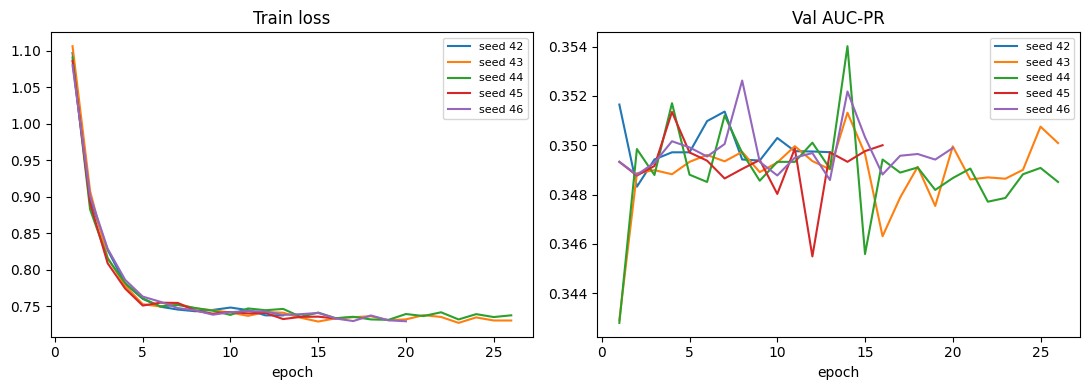

wrote C:\Users\nanda\OneDrive\Desktop\Capstone-2027\artifacts\plots\v2_roc_pr.png


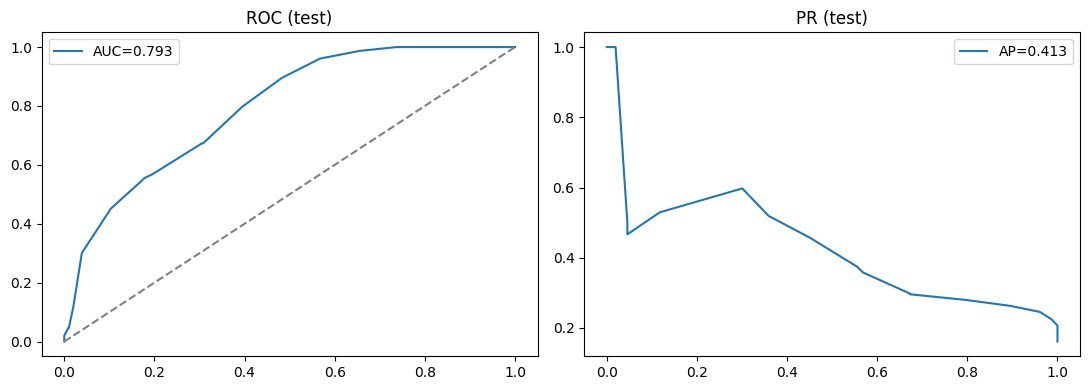

wrote C:\Users\nanda\OneDrive\Desktop\Capstone-2027\artifacts\plots\v2_confusion_matrix.png


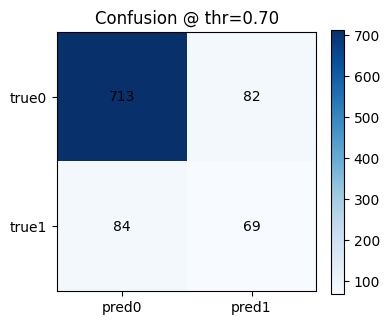

wrote C:\Users\nanda\OneDrive\Desktop\Capstone-2027\artifacts\plots\v2_score_distribution.png


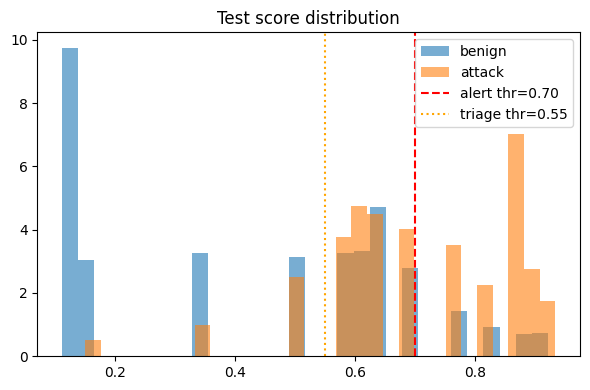

wrote C:\Users\nanda\OneDrive\Desktop\Capstone-2027\artifacts\plots\v2_threshold_sweep.png


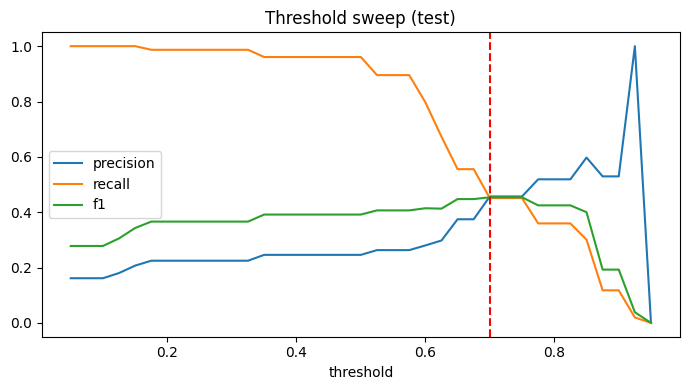

wrote C:\Users\nanda\OneDrive\Desktop\Capstone-2027\artifacts\plots\v2_metrics_bars.png


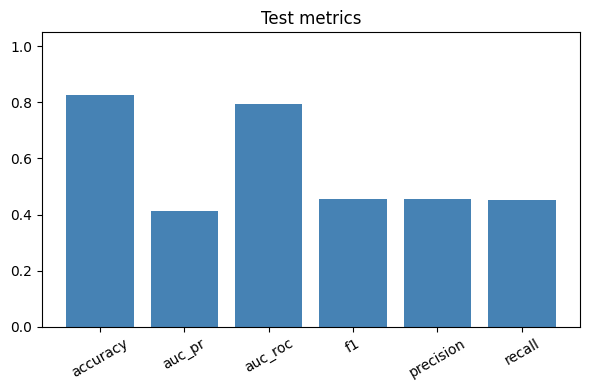

In [9]:
# Write report plots under artifacts/plots (learning curves, ROC/PR, confusion, scores, threshold sweep).

def savefig(name):
    path = PLOT_DIR / name
    plt.tight_layout()
    plt.savefig(path, dpi=120, bbox_inches="tight")
    print("wrote", path)
    plt.show()


if len(history_df):
    fig, axes = plt.subplots(1, 2, figsize=(11, 4))
    for seed, g in history_df.groupby("seed"):
        axes[0].plot(g["epoch"], g["train_loss"], label=f"seed {seed}")
        axes[1].plot(g["epoch"], g["val_auc_pr"], label=f"seed {seed}")
    axes[0].set_title("Train loss")
    axes[0].set_xlabel("epoch")
    axes[0].legend(fontsize=8)
    axes[1].set_title("Val AUC-PR")
    axes[1].set_xlabel("epoch")
    axes[1].legend(fontsize=8)
    savefig("v2_learning_curves.png")

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
fpr, tpr, _ = roc_curve(y_te, p_te)
prec, rec, _ = precision_recall_curve(y_te, p_te)
axes[0].plot(fpr, tpr, label=f"AUC={test_m['auc_roc']:.3f}")
axes[0].plot([0, 1], [0, 1], "--", color="gray")
axes[0].set_title("ROC (test)")
axes[0].legend()
axes[1].plot(rec, prec, label=f"AP={test_m['auc_pr']:.3f}")
axes[1].set_title("PR (test)")
axes[1].legend()
savefig("v2_roc_pr.png")

cm = confusion_matrix(y_te, (p_te >= threshold).astype(int))
fig, ax = plt.subplots(figsize=(4, 4))
im = ax.imshow(cm, cmap="Blues")
ax.set_xticks([0, 1]); ax.set_yticks([0, 1])
ax.set_xticklabels(["pred0", "pred1"]); ax.set_yticklabels(["true0", "true1"])
for i in range(2):
    for j in range(2):
        ax.text(j, i, int(cm[i, j]), ha="center", va="center")
ax.set_title(f"Confusion @ thr={threshold:.2f}")
fig.colorbar(im, ax=ax, fraction=0.046)
savefig("v2_confusion_matrix.png")

fig, ax = plt.subplots(figsize=(6, 4))
ax.hist(p_te[y_te == 0], bins=30, alpha=0.6, label="benign", density=True)
ax.hist(p_te[y_te == 1], bins=30, alpha=0.6, label="attack", density=True)
ax.axvline(threshold, color="red", linestyle="--", label=f"alert thr={threshold:.2f}")
ax.axvline(THR_TRIAGE, color="orange", linestyle=":", label=f"triage thr={THR_TRIAGE}")
ax.set_title("Test score distribution")
ax.legend()
savefig("v2_score_distribution.png")

# Higher threshold usually → higher precision, lower recall
ths = np.linspace(0.05, 0.95, 37)
precs, recs, f1s = [], [], []
for t in ths:
    precs.append(precision_score(y_te, (p_te >= t).astype(int), zero_division=0))
    recs.append(recall_score(y_te, (p_te >= t).astype(int), zero_division=0))
    f1s.append(f1_score(y_te, (p_te >= t).astype(int), zero_division=0))
fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(ths, precs, label="precision")
ax.plot(ths, recs, label="recall")
ax.plot(ths, f1s, label="f1")
ax.axvline(threshold, color="red", linestyle="--")
ax.set_xlabel("threshold")
ax.set_title("Threshold sweep (test)")
ax.legend()
savefig("v2_threshold_sweep.png")

fig, ax = plt.subplots(figsize=(6, 4))
keys = ["accuracy", "auc_pr", "auc_roc", "f1", "precision", "recall"]
ax.bar(keys, [test_m[k] for k in keys], color="steelblue")
ax.set_ylim(0, 1.05)
ax.set_title("Test metrics")
plt.xticks(rotation=30)
savefig("v2_metrics_bars.png")


## 10. Leave-one-attacker-out (method + saved results)

LOAO retrains while holding out one attacker username (generalization check). Full LOAO is slow on CPU, so the method stays here and saved LOAO metrics are shown from `test_metrics_v2.json` (from `train_temporal_lstm_v2.py`).


In [10]:
# LOAO: hold out one attacker username, retrain, score that user.
# Saved metrics are printed; live retrain is optional and slow.

def leave_one_attacker_out(windows, vocab_size, n_features, device, attackers, seeds=BAG_SEEDS[:3]):
    """Hold out one attacker username; retrain bag on the rest."""
    results = {}
    for held in attackers:
        train_pool = [w for w in windows if w.username != held]
        test_hold = [w for w in windows if w.username == held]
        if not test_hold or sum(w.label for w in train_pool) < 2:
            results[held] = {"error": "insufficient data"}
            continue
        try:
            tr, va, _ = group_split(train_pool)
        except Exception:
            idx = np.arange(len(train_pool))
            rng = np.random.RandomState(SEED)
            rng.shuffle(idx)
            cut = int(0.8 * len(idx))
            tr = [train_pool[i] for i in idx[:cut]]
            va = [train_pool[i] for i in idx[cut:]]
        print(f"LOAO held={held} train={len(tr)} val={len(va)} test={len(test_hold)}")
        ms, _ = train_bag(tr, va, vocab_size, n_features, device, seeds=seeds)
        y_va, p_va = predict_bag(ms, DataLoader(WindowDataset(va), batch_size=BATCH_SIZE), device)
        thr = tune_threshold(y_va, p_va) if y_va.sum() > 0 else 0.5
        y, p = predict_bag(ms, DataLoader(WindowDataset(test_hold), batch_size=BATCH_SIZE), device)
        results[held] = metrics_dict(y, p, threshold=thr)
    return results


metrics_path = OUT_DIR / "test_metrics_v2.json"
if metrics_path.exists():
    saved = json.loads(metrics_path.read_text(encoding="utf-8"))
    loao = saved.get("loao", {})
    print("Saved LOAO metrics:")
    print(json.dumps(loao, indent=2))
else:
    print("No saved LOAO yet. Run: python train_temporal_lstm_v2.py")

# Uncomment to recompute LOAO inside the notebook (slow):
# top = [u for u, _ in Counter(w.username for w in windows if w.label == 1).most_common(3)]
# loao_live = leave_one_attacker_out(windows, VOCAB_SIZE, N_FEATURES, device, top)


Saved LOAO metrics:
{
  "inv:bert-jan": {
    "accuracy": 0.2,
    "auc_pr": 0.8167678258274235,
    "auc_roc": 0.62,
    "f1": 0.0,
    "precision": 0.0,
    "recall": 0.0,
    "threshold": 0.7,
    "n": 25,
    "n_pos": 20
  },
  "fe:ezlllcsqgnr": {
    "accuracy": 0.625,
    "auc_pr": 0.9999999999999999,
    "auc_roc": 1.0,
    "f1": 0.7272727272727273,
    "precision": 1.0,
    "recall": 0.5714285714285714,
    "threshold": 0.625,
    "n": 8,
    "n_pos": 7
  },
  "fe:fula": {
    "accuracy": 0.5,
    "auc_pr": 0.9999999999999999,
    "auc_roc": 1.0,
    "f1": 0.6,
    "precision": 1.0,
    "recall": 0.42857142857142855,
    "threshold": 0.675,
    "n": 8,
    "n_pos": 7
  }
}


## 11. Fusion handoff

Export columns for joining with `P_graph`: `username`, `window_start`, `window_end`, `P_seq`, `pred_triage`, `pred_alert`.

Serving stack under `prod/` (`python -m prod.cli`, FastAPI). Spec: `prod/HANDOFF.md`.


In [11]:
# Preview fusion CSV and confirm artifacts exist.

print(pseq_df.head(8).to_string(index=False))
print("\nthreshold alert:", threshold, " triage:", THR_TRIAGE)
print("artifacts:", ckpt_path.exists(), (OUT_DIR / "P_seq_v2.csv").exists())


               username              window_start                window_end  window_label  raw_len    P_seq  pred_triage  pred_alert
fe:AWSServiceRoleForEC2 2024-03-24T06:52:00+00:00 2024-03-24T07:02:00+00:00             0        7 0.605419            1           0
fe:AWSServiceRoleForEC2 2024-03-24T06:54:00+00:00 2024-03-24T07:04:00+00:00             0        7 0.605419            1           0
fe:AWSServiceRoleForEC2 2024-03-24T06:56:00+00:00 2024-03-24T07:06:00+00:00             0        7 0.605419            1           0
fe:AWSServiceRoleForEC2 2024-03-24T06:58:00+00:00 2024-03-24T07:08:00+00:00             0        7 0.605419            1           0
fe:AWSServiceRoleForEC2 2024-03-24T07:00:00+00:00 2024-03-24T07:10:00+00:00             0        7 0.605419            1           0
fe:AWSServiceRoleForEC2 2024-04-11T06:52:00+00:00 2024-04-11T07:02:00+00:00             0        8 0.640341            1           0
fe:AWSServiceRoleForEC2 2024-04-11T06:54:00+00:00 2024-04-11T07:04:00